const { timeout } = require("async")
const { useActionState } = require("react")
const { jsx } = require("react/jsx-runtime")

default javascript = 
syncronous (code executes in sequence)
single threaded language(everything exectes on single thread)

global execution context 
. executes one line of code at a 
.each oprn waits for last one to complete executing
. we have call stack and memory heap in jsx




# blocking code vs Non-blocking code

blocking = block the flow of program
          read file sync (while file is getting read all the other executions stop)


non-blocking code = doesnt block execution
                   read file async (while file is getting read other executions doesnt stop)

none is good or bad , depends on ur useActionState


javascript engine = (memory heap + call stack)



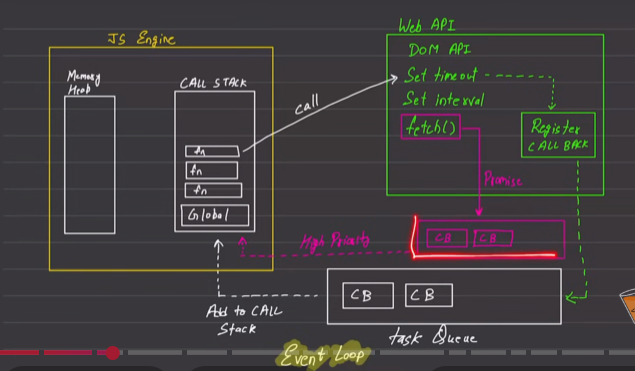

JAVASCRIPT EVENT LOOP ARCHITECTURE NOTES

1. JAVASCRIPT ENGINE
   The JavaScript engine executes JavaScript code. It contains two main parts:

a) Memory Heap

* Stores variables and objects
* Dynamic memory allocation happens here

Example:
let x = 10
let obj = {name: "Shubh"}

b) Call Stack

* Keeps track of function execution
* Uses LIFO (Last In First Out)

Example execution:
function a(){
b()
}

function b(){
console.log("Hello")
}

Call stack flow:
a() -> b() -> console.log()

2. WEB APIs (Browser Environment)
   Web APIs are provided by the browser, not by JavaScript itself.

Examples:

* setTimeout()
* setInterval()
* fetch()
* DOM APIs
* Event listeners

When an async function is called, the browser handles it using Web APIs.

3. CALLBACK REGISTRATION
   When asynchronous functions like setTimeout or fetch are called:

Step 1: Function enters the Call Stack
Step 2: It is handed to the Web API
Step 3: Web API registers the callback
Step 4: After completion, the callback is sent to a queue

4. TASK QUEUE (Callback Queue)
   Stores callbacks from:

* setTimeout
* setInterval
* DOM events

Example queue structure:
CB
CB
CB

These callbacks wait until the Call Stack becomes empty.

5. MICROTASK QUEUE (High Priority Queue)
   Higher priority than the task queue.

Contains callbacks from:

* Promise.then()
* Promise.catch()
* Promise.finally()
* queueMicrotask()

Example:
Promise.resolve().then(() => {
console.log("Promise resolved")
})

6. EVENT LOOP
   The Event Loop continuously checks:

"Is the Call Stack empty?"

If YES:

1. Execute all Microtasks

2. Then execute tasks from the Task Queue

3. EXECUTION PRIORITY
   Order of execution:

4. Call Stack

5. Microtask Queue (Promises)

6. Task Queue (Timers, events)

7. FETCH API FLOW
   fetch() is handled by Web APIs and returns a Promise.

Flow:
fetch() -> Web API
Network request runs
Response received
Promise resolved
.then() callback goes to Microtask Queue
Event Loop sends it to Call Stack

9. EXAMPLE EXECUTION

Code:
console.log("Start")

setTimeout(() => {
console.log("Timeout")
}, 0)

Promise.resolve().then(() => {
console.log("Promise")
})

console.log("End")

Execution Order:
Start
End
Promise
Timeoutt

10. COMPLETE FLOW

JavaScript Code
↓
Call Stack
↓
Async function detected
↓
Web APIs handle it
↓
Callback registered
↓
Microtask Queue or Task Queue
↓
Event Loop checks stack
↓
Callback moved to Call Stack
↓
Execution

11. IMPORTANT POINT
    JavaScript is single-threaded but achieves asynchronous behavior using:

* Web APIs
* Callback Queues
* Event Loop
